# Home Credit - Exploratory Data Analysis (EDA)

**Objectives**:
1. Understand the base table structure and target distribution
2. Analyze WEEK_NUM distribution (critical for time-based CV)
3. Explore target rate over time (temporal stability)
4. Examine depth-1 table structure for feature engineering
5. Assess missingness patterns

**Key insight for this competition**: The evaluation metric penalizes temporal degradation, so understanding how data changes over WEEK_NUM is crucial.

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Paths
TRAIN_DIR = Path("../data/raw/parquet_files/train")
TEST_DIR = Path("../data/raw/parquet_files/test")

print(f"Train dir exists: {TRAIN_DIR.exists()}")
print(f"Test dir exists: {TEST_DIR.exists()}")

Train dir exists: True
Test dir exists: True


## 1. Base Table Overview

In [2]:
# Load base tables
base_train = pl.read_parquet(TRAIN_DIR / "train_base.parquet")
base_test = pl.read_parquet(TEST_DIR / "test_base.parquet")

print("="*60)
print("BASE TABLE OVERVIEW")
print("="*60)
print(f"\nTrain shape: {base_train.shape}")
print(f"Test shape: {base_test.shape}")
print(f"\nColumns: {base_train.columns}")
print(f"\nData types:")
print(base_train.dtypes)

BASE TABLE OVERVIEW

Train shape: (1526659, 5)
Test shape: (10, 4)

Columns: ['case_id', 'date_decision', 'MONTH', 'WEEK_NUM', 'target']

Data types:
[Int64, String, Int64, Int64, Int64]


In [3]:
# Preview data
print("Sample rows:")
base_train.head(10)

Sample rows:


case_id,date_decision,MONTH,WEEK_NUM,target
i64,str,i64,i64,i64
0,"""2019-01-03""",201901,0,0
1,"""2019-01-03""",201901,0,0
2,"""2019-01-04""",201901,0,0
3,"""2019-01-03""",201901,0,0
4,"""2019-01-04""",201901,0,1
5,"""2019-01-02""",201901,0,0
6,"""2019-01-03""",201901,0,0
7,"""2019-01-03""",201901,0,0
8,"""2019-01-03""",201901,0,0


## 2. Target Distribution

In [4]:
# Target distribution
target_counts = base_train.select("target").to_series().value_counts().sort("target")
print("Target Distribution:")
print(target_counts)

total = target_counts["count"].sum()
positive = target_counts.filter(pl.col("target") == 1)["count"][0]
negative = target_counts.filter(pl.col("target") == 0)["count"][0]

print(f"\nPositive (default): {positive:,} ({100*positive/total:.2f}%)")
print(f"Negative (no default): {negative:,} ({100*negative/total:.2f}%)")
print(f"Imbalance ratio: {negative/positive:.1f}:1")

Target Distribution:
shape: (2, 2)
┌────────┬─────────┐
│ target ┆ count   │
│ ---    ┆ ---     │
│ i64    ┆ u32     │
╞════════╪═════════╡
│ 0      ┆ 1478665 │
│ 1      ┆ 47994   │
└────────┴─────────┘

Positive (default): 47,994 (3.14%)
Negative (no default): 1,478,665 (96.86%)
Imbalance ratio: 30.8:1


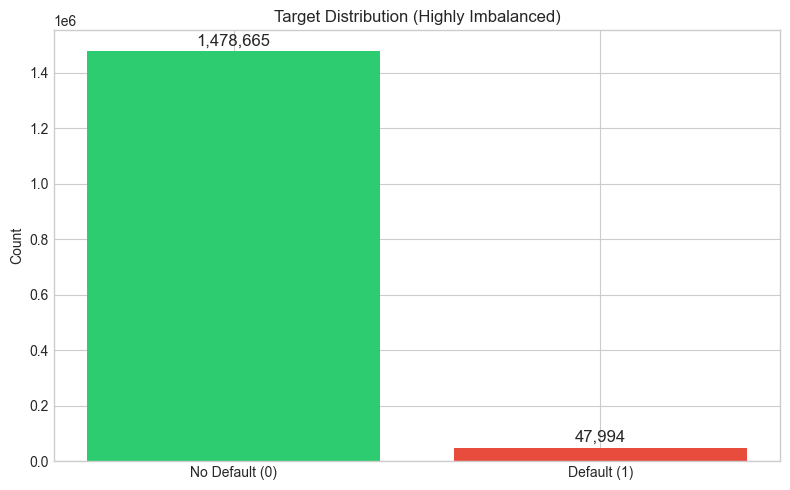

In [5]:
# Visualize target distribution
fig, ax = plt.subplots(figsize=(8, 5))
target_df = target_counts.to_pandas()
bars = ax.bar(['No Default (0)', 'Default (1)'], target_df['count'], color=['#2ecc71', '#e74c3c'])
ax.set_ylabel('Count')
ax.set_title('Target Distribution (Highly Imbalanced)')

# Add count labels
for bar, count in zip(bars, target_df['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000, 
            f'{count:,}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

## 3. WEEK_NUM Analysis (Critical for Time-Based CV)

In [6]:
# WEEK_NUM distribution
week_stats = base_train.select("WEEK_NUM").describe()
print("WEEK_NUM Statistics:")
print(week_stats)

min_week = base_train.select("WEEK_NUM").min().item()
max_week = base_train.select("WEEK_NUM").max().item()
print(f"\nWeek range: {min_week} to {max_week} ({max_week - min_week + 1} weeks)")

WEEK_NUM Statistics:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ WEEK_NUM   │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 1.526659e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 40.769036  │
│ std        ┆ 23.797981  │
│ min        ┆ 0.0        │
│ 25%        ┆ 23.0       │
│ 50%        ┆ 40.0       │
│ 75%        ┆ 55.0       │
│ max        ┆ 91.0       │
└────────────┴────────────┘

Week range: 0 to 91 (92 weeks)


In [7]:
# Applications per week
weekly_counts = base_train.group_by("WEEK_NUM").agg(
    pl.count().alias("applications"),
    pl.col("target").sum().alias("defaults"),
    pl.col("target").mean().alias("default_rate")
).sort("WEEK_NUM")

weekly_df = weekly_counts.to_pandas()

print("Weekly statistics (first 10 weeks):")
print(weekly_df.head(10))

Weekly statistics (first 10 weeks):
   WEEK_NUM  applications  defaults  default_rate
0         0         16735       400      0.023902
1         1         18841       472      0.025052
2         2         17476       465      0.026608
3         3         16108       419      0.026012
4         4         14309       404      0.028234
5         5         15335       407      0.026541
6         6         16385       445      0.027159
7         7         17238       462      0.026801
8         8         13076       424      0.032426
9         9         14716       390      0.026502


/var/folders/vl/q2sd0w8x5354502s1dhjjnr40000gn/T/ipykernel_58660/1419441304.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("applications"),


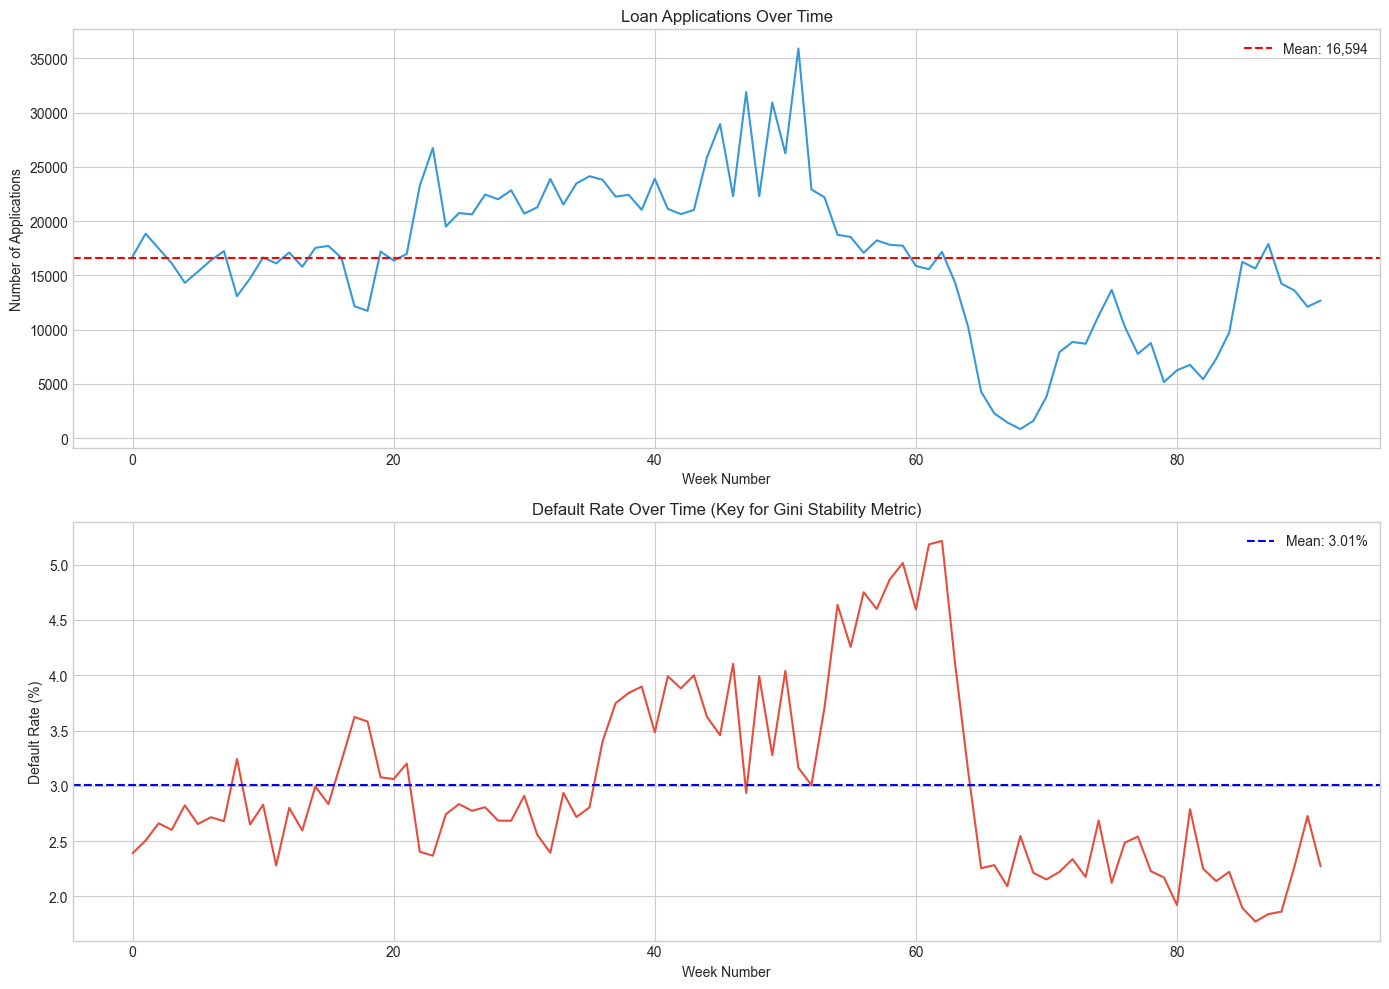

In [8]:
# Visualize applications over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Applications per week
axes[0].plot(weekly_df['WEEK_NUM'], weekly_df['applications'], color='#3498db', linewidth=1.5)
axes[0].set_xlabel('Week Number')
axes[0].set_ylabel('Number of Applications')
axes[0].set_title('Loan Applications Over Time')
axes[0].axhline(y=weekly_df['applications'].mean(), color='red', linestyle='--', label=f'Mean: {weekly_df["applications"].mean():,.0f}')
axes[0].legend()

# Default rate per week (THIS IS CRITICAL FOR STABILITY)
axes[1].plot(weekly_df['WEEK_NUM'], weekly_df['default_rate'] * 100, color='#e74c3c', linewidth=1.5)
axes[1].set_xlabel('Week Number')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_title('Default Rate Over Time (Key for Gini Stability Metric)')
axes[1].axhline(y=weekly_df['default_rate'].mean() * 100, color='blue', linestyle='--', 
                label=f'Mean: {weekly_df["default_rate"].mean()*100:.2f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# Analyze default rate trend (important for stability metric)
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(
    weekly_df['WEEK_NUM'], 
    weekly_df['default_rate']
)

print("Default Rate Trend Analysis:")
print(f"  Slope: {slope:.6f} (per week)")
print(f"  R-squared: {r_value**2:.4f}")
print(f"  P-value: {p_value:.4f}")

if slope > 0:
    print(f"\n⚠️  Default rate is INCREASING over time")
else:
    print(f"\n✅ Default rate is DECREASING over time")

print(f"\nThis trend affects the Gini stability metric!")

Default Rate Trend Analysis:
  Slope: -0.000039 (per week)
  R-squared: 0.0159
  P-value: 0.2304

✅ Default rate is DECREASING over time

This trend affects the Gini stability metric!


## 4. MONTH Analysis

In [10]:
# Month distribution
monthly_stats = base_train.group_by("MONTH").agg(
    pl.count().alias("applications"),
    pl.col("target").mean().alias("default_rate")
).sort("MONTH")

monthly_df = monthly_stats.to_pandas()

print("Monthly statistics:")
print(monthly_df)

Monthly statistics:
     MONTH  applications  default_rate
0   201901         75529      0.025990
1   201902         63064      0.027385
2   201903         69147      0.026755
3   201904         72012      0.029453
4   201905         64594      0.033006
5   201906         94398      0.025753
6   201907         97566      0.027458
7   201908         98741      0.026726
8   201909         98706      0.034030
9   201910         95149      0.038498
10  201911        115845      0.035668
11  201912        126011      0.034537
12  202001         86750      0.040772
13  202002         75183      0.046819
14  202003         60748      0.045631
15  202004          8289      0.021595
16  202005         28725      0.022106
17  202006         45962      0.024542
18  202007         28912      0.022828
19  202008         50831      0.019555
20  202009         61905      0.021517
21  202010          8592      0.021997


/var/folders/vl/q2sd0w8x5354502s1dhjjnr40000gn/T/ipykernel_58660/3682384658.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("applications"),


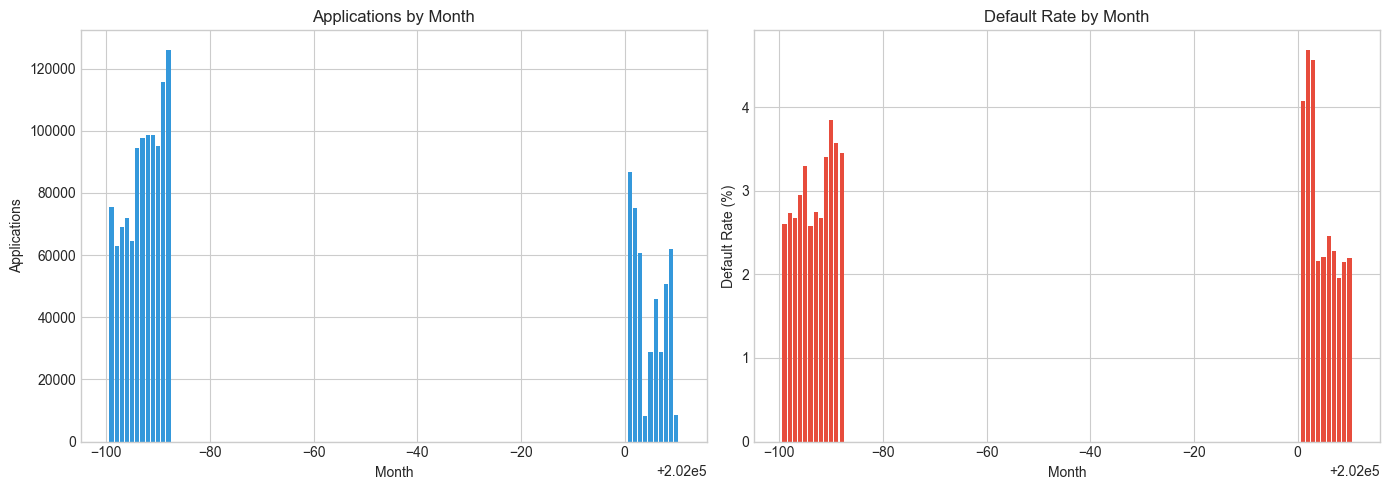

In [11]:
# Visualize monthly patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Applications by month
axes[0].bar(monthly_df['MONTH'], monthly_df['applications'], color='#3498db')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Applications')
axes[0].set_title('Applications by Month')

# Default rate by month
axes[1].bar(monthly_df['MONTH'], monthly_df['default_rate'] * 100, color='#e74c3c')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_title('Default Rate by Month')

plt.tight_layout()
plt.show()

## 5. Depth-1 Tables Overview

The competition data is hierarchical:
- **Depth 0**: Base table (1 row per application)
- **Depth 1**: Historical data (multiple rows per application)
- **Depth 2**: Even more granular data

For feature engineering, we'll aggregate depth-1 tables.

In [12]:
# List all available tables
train_files = sorted(TRAIN_DIR.glob("*.parquet"))

print("Available training tables:")
print("="*60)

# Group files by table type
import re
table_names = set()
for f in train_files:
    # Extract table name (remove _0, _1 suffixes)
    name = re.sub(r'_\d+\.parquet$', '', f.name)
    table_names.add(name)

for name in sorted(table_names):
    # Count files for this table
    files = list(TRAIN_DIR.glob(f"{name}*.parquet"))
    total_size = sum(f.stat().st_size for f in files) / (1024 * 1024)  # MB
    print(f"  {name}: {len(files)} file(s), {total_size:.1f} MB")

Available training tables:
  train_applprev: 3 file(s), 198.6 MB
  train_applprev_1: 2 file(s), 171.5 MB
  train_base.parquet: 0 file(s), 0.0 MB
  train_credit_bureau_a_1: 4 file(s), 422.9 MB
  train_credit_bureau_a_2: 11 file(s), 312.2 MB
  train_credit_bureau_b: 2 file(s), 6.3 MB
  train_debitcard: 1 file(s), 1.1 MB
  train_deposit: 1 file(s), 1.5 MB
  train_other: 1 file(s), 0.8 MB
  train_person: 2 file(s), 49.1 MB
  train_static_0: 2 file(s), 179.8 MB
  train_static_cb: 1 file(s), 29.2 MB
  train_tax_registry_a: 1 file(s), 20.7 MB
  train_tax_registry_b: 1 file(s), 9.5 MB
  train_tax_registry_c: 1 file(s), 28.4 MB


In [13]:
# Analyze key depth-1 tables
depth1_tables = [
    "train_applprev_1",
    "train_credit_bureau_a_1", 
    "train_credit_bureau_b_1",
    "train_person_1",
]

print("Depth-1 Tables Summary:")
print("="*80)

depth1_summary = []

for table in depth1_tables:
    # Find files
    files = sorted(TRAIN_DIR.glob(f"{table}*.parquet"))
    if not files:
        continue
    
    # Load first file to get schema
    df = pl.read_parquet(files[0])
    
    # Count unique case_ids
    n_unique = df.select("case_id").n_unique()
    rows_per_case = len(df) / n_unique if n_unique > 0 else 0
    
    summary = {
        'table': table.replace('train_', ''),
        'files': len(files),
        'columns': len(df.columns),
        'rows_sample': len(df),
        'unique_cases': n_unique,
        'rows_per_case': rows_per_case
    }
    depth1_summary.append(summary)
    
    print(f"\n{table.replace('train_', '').upper()}:")
    print(f"  Files: {len(files)}")
    print(f"  Columns: {len(df.columns)}")
    print(f"  Rows (first file): {len(df):,}")
    print(f"  Unique case_ids: {n_unique:,}")
    print(f"  Avg rows per case: {rows_per_case:.2f}")

# Summary table
print("\n" + "="*80)
print("SUMMARY TABLE:")
summary_df = pd.DataFrame(depth1_summary)
print(summary_df.to_string(index=False))

Depth-1 Tables Summary:



APPLPREV_1:
  Files: 2
  Columns: 41
  Rows (first file): 3,887,684
  Unique case_ids: 782,997
  Avg rows per case: 4.97



CREDIT_BUREAU_A_1:
  Files: 4
  Columns: 79
  Rows (first file): 4,108,212
  Unique case_ids: 335,275
  Avg rows per case: 12.25

CREDIT_BUREAU_B_1:
  Files: 1
  Columns: 45
  Rows (first file): 85,791
  Unique case_ids: 36,500
  Avg rows per case: 2.35



PERSON_1:
  Files: 1
  Columns: 37
  Rows (first file): 2,973,991
  Unique case_ids: 1,526,659
  Avg rows per case: 1.95

SUMMARY TABLE:
            table  files  columns  rows_sample  unique_cases  rows_per_case
       applprev_1      2       41      3887684        782997       4.965133
credit_bureau_a_1      4       79      4108212        335275      12.253261
credit_bureau_b_1      1       45        85791         36500       2.350438
         person_1      1       37      2973991       1526659       1.948039


In [14]:
# Examine column naming conventions
# Load a sample to understand column suffixes
sample_df = pl.read_parquet(TRAIN_DIR / "train_applprev_1_0.parquet")

print("Column Naming Convention Analysis (applprev_1):")
print("="*60)

# Categorize by suffix
suffix_patterns = {
    'P': 'Numeric (percentage/rate)',
    'A': 'Numeric (amount)',
    'L': 'Numeric (length/count)',
    'M': 'Categorical',
    'D': 'Date',
    'T': 'Time period'
}

suffix_counts = {}
for col in sample_df.columns:
    if col in ['case_id', 'num_group1', 'num_group2']:
        continue
    # Get last character
    last_char = col[-1] if col else ''
    if last_char in suffix_patterns:
        suffix_counts[last_char] = suffix_counts.get(last_char, 0) + 1

print("\nColumn suffix distribution:")
for suffix, count in sorted(suffix_counts.items()):
    desc = suffix_patterns.get(suffix, 'Unknown')
    print(f"  _{suffix}: {count} columns - {desc}")

print(f"\nSample columns:")
for col in sample_df.columns[:10]:
    print(f"  {col}")

Column Naming Convention Analysis (applprev_1):

Column suffix distribution:
  _A: 11 columns - Numeric (amount)
  _D: 7 columns - Date
  _L: 12 columns - Numeric (length/count)
  _M: 7 columns - Categorical
  _P: 2 columns - Numeric (percentage/rate)

Sample columns:
  case_id
  actualdpd_943P
  annuity_853A
  approvaldate_319D
  byoccupationinc_3656910L
  cancelreason_3545846M
  childnum_21L
  creationdate_885D
  credacc_actualbalance_314A
  credacc_credlmt_575A


## 6. Missingness Analysis

In [15]:
# Missingness in base table
print("Missingness in Base Table:")
print("="*60)

null_counts = base_train.null_count()
for col in base_train.columns:
    nulls = null_counts.select(col).item()
    pct = 100 * nulls / len(base_train)
    print(f"  {col}: {nulls:,} ({pct:.2f}%)")

Missingness in Base Table:
  case_id: 0 (0.00%)
  date_decision: 0 (0.00%)
  MONTH: 0 (0.00%)
  WEEK_NUM: 0 (0.00%)
  target: 0 (0.00%)


In [16]:
# Missingness in depth-1 tables (sample)
print("\nMissingness in Depth-1 Tables (sampled):")
print("="*60)

for table in ["train_applprev_1_0", "train_credit_bureau_b_1", "train_person_1"]:
    try:
        df = pl.read_parquet(TRAIN_DIR / f"{table}.parquet")
        total_cells = len(df) * len(df.columns)
        total_nulls = df.null_count().sum_horizontal()[0]
        null_pct = 100 * total_nulls / total_cells
        print(f"  {table}: {null_pct:.1f}% missing")
    except Exception as e:
        print(f"  {table}: Error - {e}")


Missingness in Depth-1 Tables (sampled):


  train_applprev_1_0: 30.9% missing
  train_credit_bureau_b_1: 29.1% missing
  train_person_1: 46.4% missing


## 7. Train vs Test Comparison

In [17]:
# Compare train and test
print("Train vs Test Comparison:")
print("="*60)

print(f"\nTrain:")
print(f"  Rows: {len(base_train):,}")
print(f"  WEEK_NUM range: {base_train['WEEK_NUM'].min()} - {base_train['WEEK_NUM'].max()}")
print(f"  Has target: Yes")

print(f"\nTest:")
print(f"  Rows: {len(base_test):,}")
print(f"  WEEK_NUM range: {base_test['WEEK_NUM'].min()} - {base_test['WEEK_NUM'].max()}")
print(f"  Has target: {'target' in base_test.columns}")

print(f"\nTest columns: {base_test.columns}")

Train vs Test Comparison:

Train:
  Rows: 1,526,659
  WEEK_NUM range: 0 - 91
  Has target: Yes

Test:
  Rows: 10
  WEEK_NUM range: 100 - 100
  Has target: False

Test columns: ['case_id', 'date_decision', 'MONTH', 'WEEK_NUM']


## 8. Key Insights for Modeling

### Findings Summary

In [18]:
print("="*80)
print("KEY INSIGHTS FOR MODELING")
print("="*80)

print(f"""
1. TARGET IMBALANCE
   - Default rate: ~3.1% (highly imbalanced)
   - Ratio: ~30:1 (non-default : default)
   - Consider: class weights, oversampling, or threshold tuning

2. TEMPORAL STRUCTURE (Critical for this competition!)
   - {max_week - min_week + 1} weeks of data
   - Default rate {'increases' if slope > 0 else 'decreases'} over time
   - MUST use time-based CV (not random split)
   - Train on earlier weeks, validate on later weeks

3. DATA SCALE
   - ~1.5M training applications
   - Multiple depth-1 tables with millions of rows
   - Use Polars for memory efficiency

4. FEATURE ENGINEERING OPPORTUNITIES
   - applprev_1: Previous loan applications (~2 per customer)
   - credit_bureau_a/b: Credit history (~2-11 records per customer)
   - person_1: Demographics (~4 records per customer)
   - Aggregate by case_id with mean, max, min, std, count

5. COMPETITION METRIC: GINI STABILITY
   - Not just AUC, but stability over time
   - Features that degrade over WEEK_NUM will hurt score
   - May need to drop temporally unstable features
""")

KEY INSIGHTS FOR MODELING

1. TARGET IMBALANCE
   - Default rate: ~3.1% (highly imbalanced)
   - Ratio: ~30:1 (non-default : default)
   - Consider: class weights, oversampling, or threshold tuning

2. TEMPORAL STRUCTURE (Critical for this competition!)
   - 92 weeks of data
   - Default rate decreases over time
   - MUST use time-based CV (not random split)
   - Train on earlier weeks, validate on later weeks

3. DATA SCALE
   - ~1.5M training applications
   - Multiple depth-1 tables with millions of rows
   - Use Polars for memory efficiency

4. FEATURE ENGINEERING OPPORTUNITIES
   - applprev_1: Previous loan applications (~2 per customer)
   - credit_bureau_a/b: Credit history (~2-11 records per customer)
   - person_1: Demographics (~4 records per customer)
   - Aggregate by case_id with mean, max, min, std, count

5. COMPETITION METRIC: GINI STABILITY
   - Not just AUC, but stability over time
   - Features that degrade over WEEK_NUM will hurt score
   - May need to drop temporal

## 9. Recommended CV Strategy

In [19]:
# Suggest train/val split based on WEEK_NUM
week_80 = int(base_train['WEEK_NUM'].quantile(0.8))

train_weeks = base_train.filter(pl.col('WEEK_NUM') <= week_80)
val_weeks = base_train.filter(pl.col('WEEK_NUM') > week_80)

print("Recommended Time-Based CV Split:")
print("="*60)
print(f"\nTrain: WEEK_NUM <= {week_80}")
print(f"  Rows: {len(train_weeks):,}")
print(f"  Weeks: {train_weeks['WEEK_NUM'].min()} - {train_weeks['WEEK_NUM'].max()}")
print(f"  Default rate: {train_weeks['target'].mean()*100:.2f}%")

print(f"\nValidation: WEEK_NUM > {week_80}")
print(f"  Rows: {len(val_weeks):,}")
print(f"  Weeks: {val_weeks['WEEK_NUM'].min()} - {val_weeks['WEEK_NUM'].max()}")
print(f"  Default rate: {val_weeks['target'].mean()*100:.2f}%")

print(f"\n⚠️  Note: Use WEEK_NUM-based split, NOT random split!")

Recommended Time-Based CV Split:

Train: WEEK_NUM <= 60
  Rows: 1,235,013
  Weeks: 0 - 60
  Default rate: 3.26%

Validation: WEEK_NUM > 60
  Rows: 291,646
  Weeks: 61 - 91
  Default rate: 2.66%

⚠️  Note: Use WEEK_NUM-based split, NOT random split!


## 10. Save EDA Summary for Report

In [20]:
# Create summary for report
eda_summary = {
    'train_rows': len(base_train),
    'test_rows': len(base_test),
    'default_rate': float(base_train['target'].mean()),
    'imbalance_ratio': negative / positive,
    'week_range': (min_week, max_week),
    'n_weeks': max_week - min_week + 1,
    'default_trend_slope': slope,
    'cv_split_week': week_80,
}

print("EDA Summary (for report):")
for key, value in eda_summary.items():
    print(f"  {key}: {value}")

EDA Summary (for report):
  train_rows: 1526659
  test_rows: 10
  default_rate: 0.03143727577671242
  imbalance_ratio: 30.80937200483394
  week_range: (0, 91)
  n_weeks: 92
  default_trend_slope: -3.9294272200509806e-05
  cv_split_week: 60
